# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Amr Yasser Doma
**Student ID:** 1210273

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [2]:
# Write your Data Pipeline code here
df = pd.read_csv('kidney_disease.csv')
df.head()
df['classification'] = df['classification'].str.strip()
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0})

In [3]:
y = df['classification']
X = df.drop(columns=['id', 'classification'], errors='ignore')

X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna(axis=1, how='all')
X = X.fillna(X.median())

df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,1
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,1
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,1
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,1
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,1


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Features kept: {list(X.columns)}")
print(f"Target distribution:\n{y.value_counts()}")

Features kept: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
Target distribution:
classification
1    250
0    150
Name: count, dtype: int64


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

In [5]:
# Write your Baseline Model code here
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

model_1 = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_1.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=[tf.keras.metrics.Recall(name='recall')]
)

history_fail = model_1.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=16,
    verbose=0
)

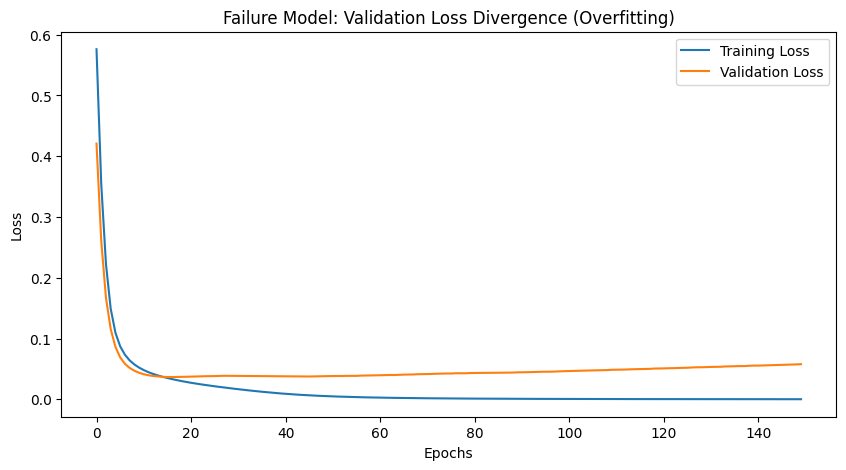

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(history_fail.history['loss'], label='Training Loss')
plt.plot(history_fail.history['val_loss'], label='Validation Loss')
plt.title('Failure Model: Validation Loss Divergence (Overfitting)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

In [7]:
from tensorflow.keras import regularizers, callbacks

# Identical architecture + Regularization
model_2 = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),

    layers.Dense(64, kernel_regularizer=regularizers.l2(0.01)),
    layers.LeakyReLU(alpha=0.1),
    layers.Dropout(0.4),

    layers.Dense(32, kernel_regularizer=regularizers.l2(0.01)),
    layers.LeakyReLU(alpha=0.1),
    layers.Dropout(0.3),
    
    layers.Dense(1, activation='sigmoid')
])

model_2.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=[tf.keras.metrics.Recall(name='recall')]
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True
)

history_clinical = model_2.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

c:\Users\amrdo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

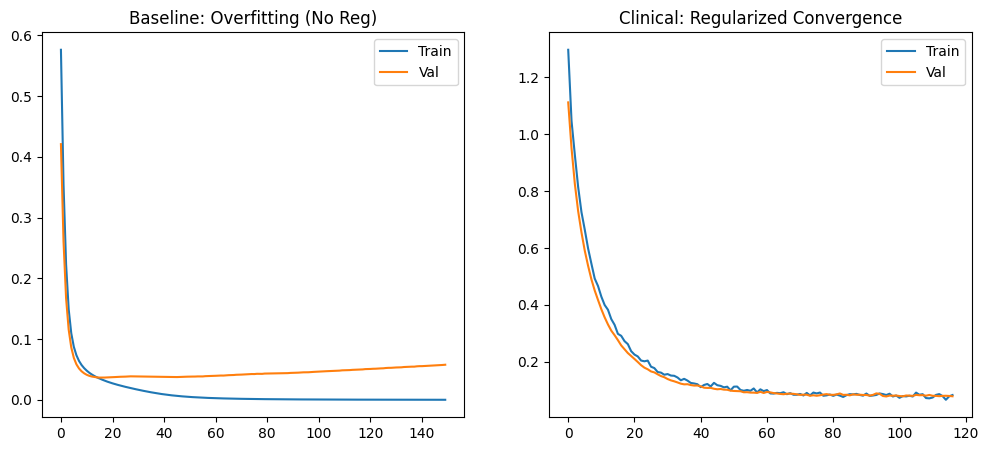

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Baseline Recall: 96.00%
Clinical Recall: 100.00%


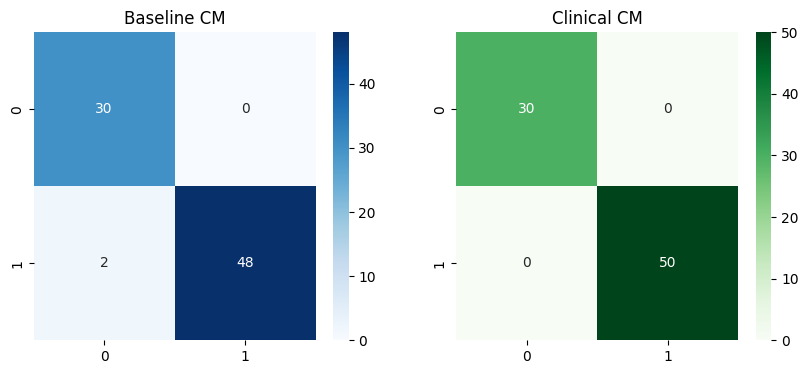

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, recall_score

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_fail.history['loss'], label='Train')
plt.plot(history_fail.history['val_loss'], label='Val')
plt.title('Baseline: Overfitting (No Reg)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_clinical.history['loss'], label='Train')
plt.plot(history_clinical.history['val_loss'], label='Val')
plt.title('Clinical: Regularized Convergence')
plt.legend()
plt.show()

y_pred_fail = (model_1.predict(X_val_scaled) > 0.5).astype(int)
y_pred_clinical = (model_2.predict(X_val_scaled) > 0.5).astype(int)

rec_fail = recall_score(y_val, y_pred_fail)
rec_clinical = recall_score(y_val, y_pred_clinical)

print(f"Baseline Recall: {rec_fail:.2%}")
print(f"Clinical Recall: {rec_clinical:.2%}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(confusion_matrix(y_val, y_pred_fail), annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title("Baseline CM")
sns.heatmap(confusion_matrix(y_val, y_pred_clinical), annot=True, fmt='d', ax=ax[1], cmap='Greens')
ax[1].set_title("Clinical CM")
plt.show()

In [9]:
from sklearn.metrics import classification_report, roc_auc_score

def print_clinical_metrics(model, X, y, label="Model"):
    probs = model.predict(X).ravel()
    preds = (probs > 0.5).astype(int)
    report = classification_report(y, preds, target_names=['Healthy', 'CKD'], output_dict=True)
    auc = roc_auc_score(y, probs)
    
    print(f"--- {label} Performance ---")
    print(f"Recall (Sensitivity): {report['CKD']['recall']:.4f}")
    print(f"Precision:            {report['CKD']['precision']:.4f}")
    print(f"F1-Score:             {report['CKD']['f1-score']:.4f}")
    print(f"AUC-ROC:              {auc:.4f}")
    print("-" * 30)

print_clinical_metrics(model_1, X_val_scaled, y_val, label="Baseline Model")
print_clinical_metrics(model_2, X_val_scaled, y_val, label="Engineered Model")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
--- Baseline Model Performance ---
Recall (Sensitivity): 0.9600
Precision:            1.0000
F1-Score:             0.9796
AUC-ROC:              0.9980
------------------------------
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
--- Engineered Model Performance ---
Recall (Sensitivity): 1.0000
Precision:            1.0000
F1-Score:             1.0000
AUC-ROC:              1.0000
------------------------------


In [10]:
param_count = model_1.count_params()
print(f"Final Parameter Count: {param_count}")

Final Parameter Count: 3073


### Mathematical Justification
**Final Parameter Count of Engineered Model:** 3073

**Explanation:** Even tho the first one has 0.96 recall, it means 2 patients were false negatives. So the second model saved the life of 2 patients by using dropout and L2.